In [10]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [12]:
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from scipy.sparse import coo_matrix

In [15]:
edges, n_vertices, edge_weights = load_graph("../../data/raw/oregon1_010526.txt")

✓ Loaded: ../../data/raw/oregon1_010526.txt
  Vertices : 11174
  Edges    : 23409
  Weighted : no



In [19]:
import networkx as nx

G_nx = nx.Graph()
G_nx.add_edges_from(edges)

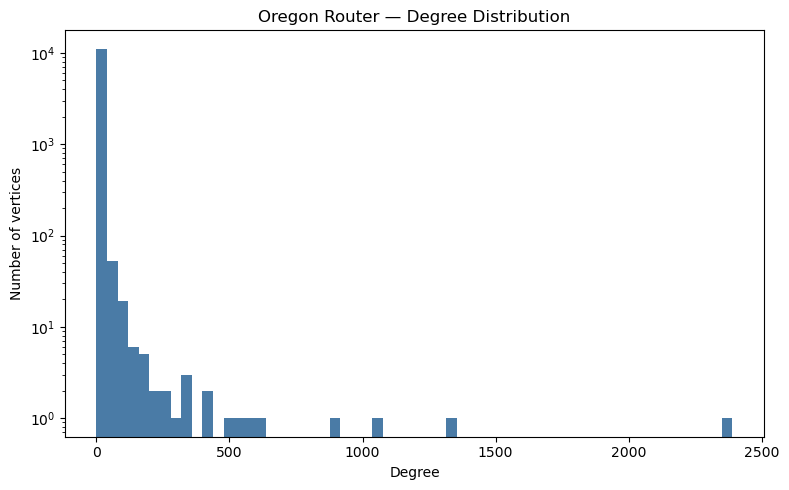

Computing layout (this will take a couple minutes at 11,174 vertices)...


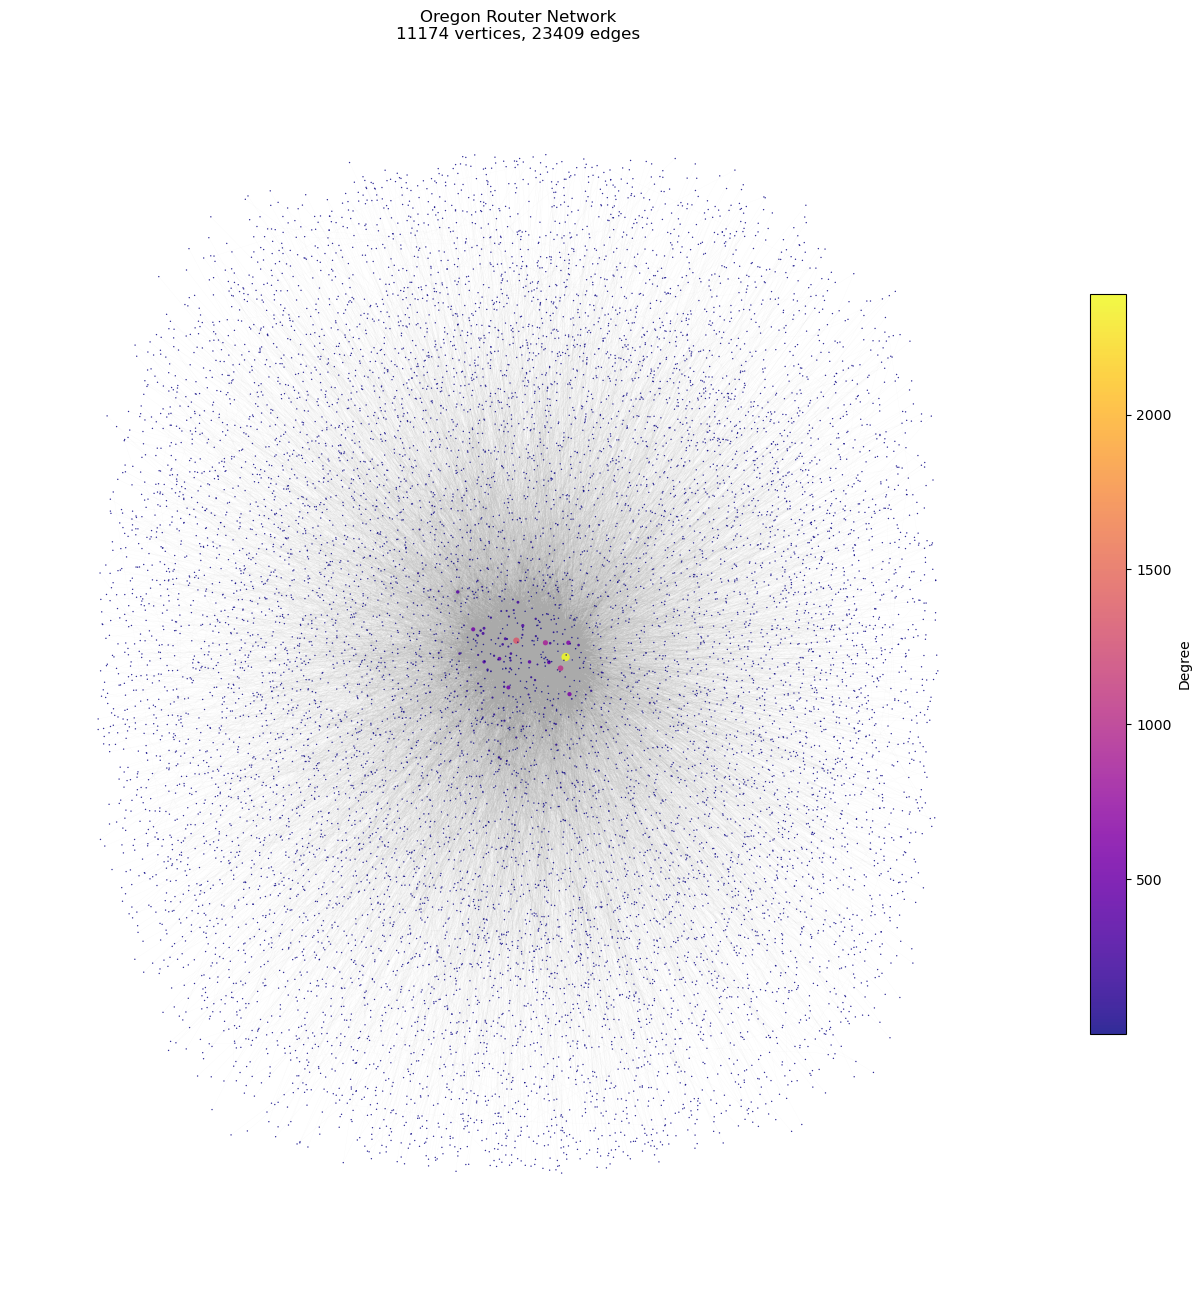

In [21]:
import matplotlib.pyplot as plt
import numpy as np

degrees = dict(G_nx.degree())
deg_values = np.array([degrees[n] for n in G_nx.nodes()])

# --- Degree distribution (recommended for the paper — clear, scales well) ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(deg_values, bins=60, color='#4a7ba6', edgecolor='none')
ax.set_xlabel('Degree')
ax.set_ylabel('Number of vertices')
ax.set_yscale('log')
ax.set_title('Oregon Router — Degree Distribution')
plt.tight_layout()
plt.savefig('oregon_degree_dist.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Computing layout (this will take a couple minutes at 11,174 vertices)...


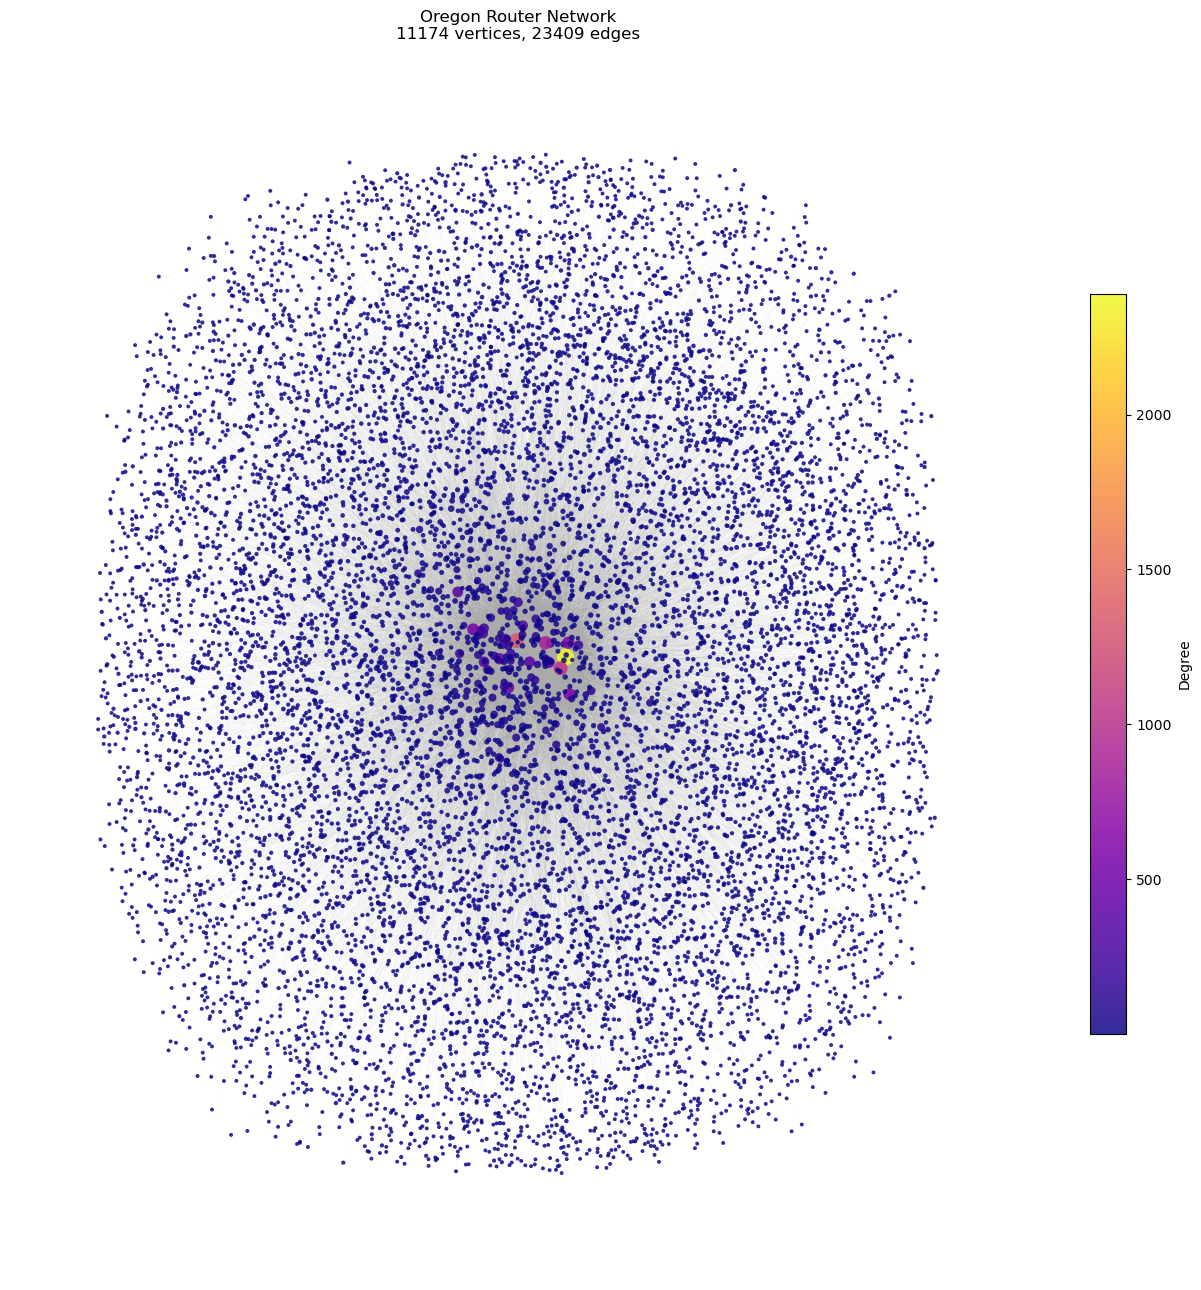

In [25]:
# --- Network structure (optional, illustrative only — will be slow and dense at this scale) ---
print("Computing layout (this will take a couple minutes at 11,174 vertices)...")
pos = nx.spring_layout(G_nx, seed=7, k=0.05, iterations=10)

fig, ax = plt.subplots(figsize=(13, 13), facecolor='white')
nx.draw_networkx_edges(G_nx, pos, ax=ax, width=0.08, edge_color='#aaaaaa', alpha=0.2)
node_sizes = 5 + np.sqrt(deg_values) * 3
nodes = nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_size=node_sizes,
                                node_color=deg_values, cmap='plasma',
                                edgecolors='none', alpha=0.85)
plt.colorbar(nodes, ax=ax, label='Degree', shrink=0.6)
ax.set_title(f"Oregon Router Network\n{G_nx.number_of_nodes()} vertices, {G_nx.number_of_edges()} edges")
ax.axis('off')
plt.tight_layout()
plt.savefig('oregon_network.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [27]:
import os
print(os.getcwd())

C:\Users\Rakesh\Documents\summer-project\notebooks\pipeline_runs


In [11]:
# check if it is connected
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
num_components = nx.number_connected_components(G_nx)
component_sizes = sorted([len(c) for c in nx.connected_components(G_nx)], reverse=True)
print(f"Connected components: {num_components}")
print(f"Component sizes: {component_sizes[:10]}")  # show top 10 in case there are many

Connected components: 1
Component sizes: [11174]


In [29]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 11174 x 11174
  Degree range: [1, 2389]
  Non-zeros in L: 57992



In [31]:
lambda_min = compute_lambda_min(L, D)

✓ lambda_min = 0.032899
  (eigenvalues found: [0.         0.03289937])


In [17]:
L_sigma  = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)



In [19]:
all_nodes = set(v for e in edges for v in e)
print(f"min: {min(all_nodes)}, max: {max(all_nodes)}, count: {len(all_nodes)}, n_vertices: {n_vertices}")

min: 0, max: 11173, count: 11174, n_vertices: 11174


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# assumes B, w, f, u, i_arr, j_arr already exist in your session from your real Oregon run
u_i_edge = u[i_arr]
u_j_edge = u[j_arr]
f_i_edge = f[i_arr]
f_j_edge = f[j_arr]

corr_u = np.corrcoef(u_i_edge, u_j_edge)[0,1]
corr_f = np.corrcoef(f_i_edge, f_j_edge)[0,1]
print(f"Correlation u_i vs u_j: {corr_u:.4f}")
print(f"Correlation f_i vs f_j: {corr_f:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor='white')

ax = axes[0]
ax.scatter(f_i_edge, f_j_edge, s=3, alpha=0.15, color='#3b5b92')
ax.plot([f.min(), f.max()], [f.min(), f.max()], '--', color='#d9534f', linewidth=1.2, label='$y=x$')
ax.set_xlabel(r'$f_i$'); ax.set_ylabel(r'$f_j$')
ax.set_title(f'Raw noise $f$\n(correlation = {corr_f:.3f})')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.scatter(u_i_edge, u_j_edge, s=3, alpha=0.15, color='#1f8a70')
ax.plot([u.min(), u.max()], [u.min(), u.max()], '--', color='#d9534f', linewidth=1.2, label='$y=x$')
ax.set_xlabel(r'$u_i$'); ax.set_ylabel(r'$u_j$')
ax.set_title(f'Spatially correlated field $u$\n(correlation = {corr_u:.3f})')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('phase3_local_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

NameError: name 'u' is not defined

In [21]:
def find_diameter_endpoints(G_nx, n_sample=5, k_hop=4):
    best_dist = 0
    best_v, best_w = None, None
    start_nodes = list(G_nx.nodes())[:n_sample]

    for start in start_nodes:
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w

    gamma_in  = set(nx.single_source_shortest_path_length(G_nx, best_v, cutoff=k_hop).keys())
    gamma_out = set(nx.single_source_shortest_path_length(G_nx, best_w, cutoff=k_hop).keys())
    gamma_in  = gamma_in - gamma_out
    gamma_out = gamma_out - gamma_in
    gamma_in  = list(map(int, gamma_in))
    gamma_out = list(map(int, gamma_out))

    print(f"✓ Diameter endpoints: vertex {best_v} and vertex {best_w}")
    print(f"  Shortest path: {best_dist} hops")
    print(f"  gamma_in: {len(gamma_in)} vertices")
    print(f"  gamma_out: {len(gamma_out)} vertices")
    return gamma_in, gamma_out, best_dist

gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

# sanity checks
overlap = set(gamma_in) & set(gamma_out)
assert len(overlap) == 0, f"Overlap found: {overlap}"
max_id = max(max(gamma_in), max(gamma_out))
assert max_id < n_vertices, "gamma contains out-of-range node ID"
print("✓ gamma_in/gamma_out validated")

✓ Diameter endpoints: vertex 3584 and vertex 2627
  Shortest path: 10 hops
  gamma_in: 11 vertices
  gamma_out: 92 vertices
✓ gamma_in/gamma_out validated


In [23]:
B = build_incidence_matrix(edges, n_vertices)
cho_cache = cho_factor(L_sigma)
w = np.random.randn(len(edges))
f = B @ w
u = cho_solve(cho_cache, np.sqrt(lambda_min) * f)

k = compute_permeability(u, edges, edge_weights)
L_k = build_weighted_laplacian(edges, n_vertices, k)
p = solve_darcy(L_k, n_vertices, gamma_in, gamma_out, debug=True)
Q = extract_qoi(p, k, edges, gamma_out)
print(f"Single-sample Q: {Q}")

Single-sample Q: 17.130443260518323


In [5]:
from scipy.sparse.linalg import splu
from scipy.sparse import csc_matrix, diags

def build_shifted_laplacian_sparse(L, D, lambda_min, sigma_squared=0.25):
    """
    Sparse version of build_shifted_laplacian — keeps L_sigma sparse
    instead of converting to dense, for use with splu-based factorization
    in Phase 3 (faster for large graphs like Oregon Router).

    Parameters
    ----------
    L, D        : sparse matrices (from build_graph_matrices)
    lambda_min  : float
    sigma_squared : float, default 0.25

    Returns
    -------
    L_sigma_sparse : scipy.sparse.csc_matrix — shifted Laplacian, sparse
    """
    L_sigma_sparse = (L + sigma_squared * lambda_min * D).tocsc()
    return L_sigma_sparse


def run_phase3_sparse(L_sigma_sparse, lambda_min, edges, n_vertices):
    """
    Sparse version of run_phase3 — uses splu instead of dense Cholesky.

    Steps (same as run_phase3):
        3a. Draw edge noise:       w_e ~ N(0,1) for every edge
        3b. Map noise to vertices: f = B @ w
        3c. Solve for u:           L_sigma @ u = sqrt(lambda_min) * f

    L_sigma_sparse is LU-factorized once here for reuse in the MC loop.

    Returns
    -------
    u   : np.ndarray (n_vertices,) — spatially correlated field
    B   : sparse incidence matrix (reuse in MC loop)
    lu  : splu factorization object (reuse in MC loop, replaces cho_cache)
    """
    B  = build_incidence_matrix(edges, n_vertices)
    lu = splu(L_sigma_sparse)

    w = np.random.randn(len(edges))
    f = B @ w
    u = lu.solve(np.sqrt(lambda_min) * f)

    print("✓ Phase 3 (sparse) complete: correlated field u generated")
    print(f"  u range: [{u.min():.4f}, {u.max():.4f}]")
    print()
    return u, B, lu


def monte_carlo_loop_sparse(L_sigma_sparse, lambda_min, edges, n_vertices,
                              gamma_in, gamma_out, edge_weights=None,
                              N=1000, debug=True):
    """
    Sparse-Cholesky (splu) version of monte_carlo_loop_tqdm — identical
    structure and hardened checks, but uses splu instead of dense
    cho_factor/cho_solve for Phase 3, targeting the dense-Cholesky
    bottleneck on large graphs (e.g. Oregon Router).
    """
    B  = build_incidence_matrix(edges, n_vertices)
    lu = splu(L_sigma_sparse)  # one-time sparse LU factorization, reused every sample

    Q_samples = np.zeros(N)
    edges_arr = np.array(edges)
    i_arr     = edges_arr[:, 0]
    j_arr     = edges_arr[:, 1]
    row_idx = np.concatenate([i_arr, j_arr, i_arr, j_arr])
    col_idx = np.concatenate([i_arr, j_arr, j_arr, i_arr])

    boundary   = set(gamma_in) | set(gamma_out)
    interior   = np.array([v for v in range(n_vertices) if v not in boundary])
    p_boundary = np.zeros(n_vertices)
    for v in gamma_in:
        p_boundary[v] = 1.0
    for v in gamma_out:
        p_boundary[v] = 0.0
    gamma_out_set = set(gamma_out)

    with tqdm(total=N, desc="Monte Carlo (sparse)", unit="sample") as pbar:
        for idx in range(N):
            # Phase 3 — sparse solve replaces cho_solve
            w = np.random.randn(len(edges))
            f = B @ w
            u = lu.solve(np.sqrt(lambda_min) * f)

            # Phase 4 — unchanged
            k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)

            # Phase 5a — unchanged
            diag_data = np.concatenate([k_vals, k_vals])
            offdiag_data = np.concatenate([-k_vals, -k_vals])
            data = np.concatenate([diag_data, offdiag_data])
            L_k  = coo_matrix((data, (row_idx, col_idx)),
                               shape=(n_vertices, n_vertices)).tocsr()

            # Phase 5b — unchanged, hardened
            L_interior = L_k[interior, :][:, interior]
            rhs        = -L_k[interior, :][:, list(boundary)] @ p_boundary[list(boundary)]
            p_interior = spsolve(L_interior, rhs)

            if debug:
                if np.any(np.isnan(p_interior)) or np.any(np.isinf(p_interior)):
                    raise ValueError(
                        f"Sample {idx}: solve produced NaN/Inf in interior pressures."
                    )

            p = np.zeros(n_vertices)
            p[interior] = p_interior
            for v in gamma_in:
                p[v] = 1.0
            for v in gamma_out:
                p[v] = 0.0

            if debug:
                tol = 1e-8
                if p[interior].min() < -tol or p[interior].max() > 1 + tol:
                    raise ValueError(
                        f"Sample {idx}: pressure out of physical bounds "
                        f"[min={p[interior].min():.6f}, max={p[interior].max():.6f}]."
                    )

            # Phase 6 — unchanged
            p_diff = np.abs(p[i_arr] - p[j_arr])
            outlet_mask = np.array([i in gamma_out_set or j in gamma_out_set
                                    for i,j in edges])
            Q_samples[idx] = np.sum(k_vals[outlet_mask] * p_diff[outlet_mask])
            pbar.update(1)
            pbar.set_postfix({"mean Q": f"{Q_samples[:idx+1].mean():.4f}"})

    print(f"\n✓ Done (sparse) — {N} samples")
    print(f"  Mean Q : {Q_samples.mean():.6f}")
    print(f"  Std Q  : {Q_samples.std():.6f}")
    return Q_samples

In [31]:
def compare_dense_vs_sparse_cholesky(L_sigma, lambda_min, B, edges, N_test=10):
    """
    Compare dense Cholesky (current pipeline) vs sparse splu for the
    L_sigma factorization + repeated solves in Phase 3.
    """
    if hasattr(L_sigma, 'toarray'):
        L_sigma_sparse = L_sigma.tocsc()
        L_sigma_dense = L_sigma.toarray()
    else:
        L_sigma_dense = L_sigma
        L_sigma_sparse = csc_matrix(L_sigma)

    print(f"L_sigma shape: {L_sigma_dense.shape}")

    print("\nFactorizing: dense Cholesky...")
    t0 = time.time()
    cho_cache = cho_factor(L_sigma_dense)
    dense_setup_time = time.time() - t0
    print(f"  Dense setup: {dense_setup_time:.3f}s")

    print("Factorizing: sparse splu...")
    t0 = time.time()
    lu = splu(L_sigma_sparse)
    sparse_setup_time = time.time() - t0
    print(f"  Sparse setup: {sparse_setup_time:.3f}s")

    dense_solve_times = []
    sparse_solve_times = []
    max_diffs = []

    for trial in range(N_test):
        w = np.random.randn(len(edges))
        f = B @ w
        rhs = np.sqrt(lambda_min) * f

        t0 = time.time()
        u_dense = cho_solve(cho_cache, rhs)
        dense_solve_times.append(time.time() - t0)

        t0 = time.time()
        u_sparse = lu.solve(rhs)
        sparse_solve_times.append(time.time() - t0)

        diff = np.max(np.abs(u_dense - u_sparse))
        max_diffs.append(diff)

    dense_solve_times = np.array(dense_solve_times)
    sparse_solve_times = np.array(sparse_solve_times)

    print(f"\n--- Per-sample solve timing (N={N_test}) ---")
    print(f"Dense  solve: mean={dense_solve_times.mean():.4f}s, std={dense_solve_times.std():.4f}s")
    print(f"Sparse solve: mean={sparse_solve_times.mean():.4f}s, std={sparse_solve_times.std():.4f}s")
    print(f"Max solution difference: {max(max_diffs):.2e}")

    N_full = 500
    dense_total = dense_setup_time + dense_solve_times.mean() * N_full
    sparse_total = sparse_setup_time + sparse_solve_times.mean() * N_full

    print(f"\n--- Extrapolated total time for N={N_full} samples ---")
    print(f"Dense  (setup + {N_full} solves): {dense_total:.1f}s ({dense_total/60:.1f} min)")
    print(f"Sparse (setup + {N_full} solves): {sparse_total:.1f}s ({sparse_total/60:.1f} min)")
    print(f"Sparse is {'FASTER' if sparse_total < dense_total else 'SLOWER'} "
          f"by {abs(dense_total - sparse_total):.1f}s "
          f"({abs(dense_total - sparse_total) / max(dense_total, sparse_total) * 100:.1f}%)")

    return {
        'dense_setup_time': dense_setup_time,
        'sparse_setup_time': sparse_setup_time,
        'dense_solve_times': dense_solve_times,
        'sparse_solve_times': sparse_solve_times,
        'max_diff': max(max_diffs),
    }

In [9]:
# 1. Build sparse L_sigma (instead of your existing dense build_shifted_laplacian)
L_sigma_sparse = build_shifted_laplacian_sparse(L, D, lambda_min)

# 2. Run the comparison script from before to confirm sparse actually wins on YOUR Oregon data
B = build_incidence_matrix(edges, n_vertices)
results = compare_dense_vs_sparse_cholesky(L_sigma, lambda_min, B, edges, N_test=10)
# (pass your existing dense L_sigma here — the function builds the sparse version internally too)

NameError: name 'L' is not defined

In [33]:
# 1. Build sparse L_sigma (instead of your existing dense build_shifted_laplacian)
L_sigma_sparse = build_shifted_laplacian_sparse(L, D, lambda_min)

# 2. Run the comparison script from before to confirm sparse actually wins on YOUR Oregon data
B = build_incidence_matrix(edges, n_vertices)
results = compare_dense_vs_sparse_cholesky(L_sigma, lambda_min, B, edges, N_test=10)
# (pass your existing dense L_sigma here — the function builds the sparse version internally too)

# 3. If sparse wins for N=500 extrapolation, run the full sparse pipeline:
Q_samples = monte_carlo_loop_sparse(
    L_sigma_sparse, lambda_min, edges, n_vertices,
    gamma_in, gamma_out, edge_weights,
    N=500, debug=True
)

L_sigma shape: (11174, 11174)

Factorizing: dense Cholesky...
  Dense setup: 28.751s
Factorizing: sparse splu...
  Sparse setup: 0.979s

--- Per-sample solve timing (N=10) ---
Dense  solve: mean=0.4651s, std=0.0793s
Sparse solve: mean=0.0070s, std=0.0037s
Max solution difference: 6.88e-15

--- Extrapolated total time for N=500 samples ---
Dense  (setup + 500 solves): 261.3s (4.4 min)
Sparse (setup + 500 solves): 4.5s (0.1 min)
Sparse is FASTER by 256.8s (98.3%)


Monte Carlo (sparse): 100%|██████████| 500/500 [03:21<00:00,  2.48sample/s, mean Q=17.0917]


✓ Done (sparse) — 500 samples
  Mean Q : 17.091731
  Std Q  : 0.342706



=== Monte Carlo Results ===
  Samples : 500
  Mean Q  : 17.091731
  Std Q   : 0.342706
  Var Q   : 0.117448
  Min Q   : 16.168491
  Max Q   : 18.207296


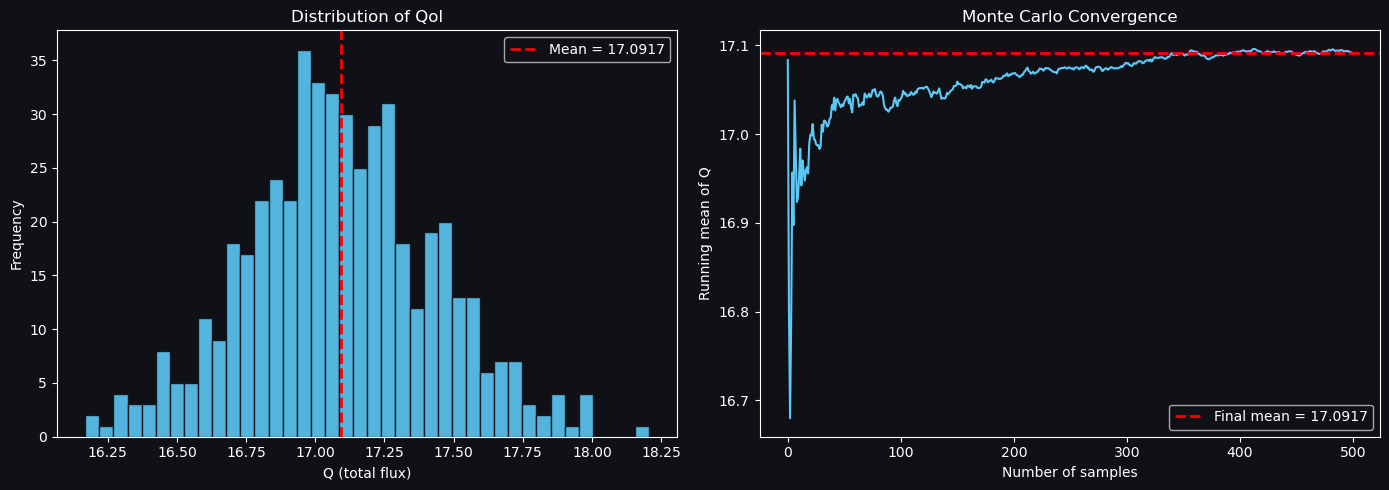

In [35]:
analyze_qoi(Q_samples)

In [11]:
Q_samples = monte_carlo_loop_sparse(
    L_sigma_sparse, lambda_min, edges, n_vertices,
    gamma_in, gamma_out, edge_weights,
    N=300, debug=True
)

NameError: name 'L_sigma_sparse' is not defined